# 10 · Beyond the best quote: our own live recording of the order book

**The question:** chapters 5 and 6 used only the *best* bid and ask. Does the rest of the book add information?

Binance stopped publishing historical order-book files in 2024, and the full-depth Nasdaq data (LOBSTER) can't be
published from (see `micro/lobster.py`). So we **recorded our own**: `scripts/record_binance.py` subscribed to
Binance's public websocket streams for BTCUSDT perpetual futures and saved

- `depth20@100ms`: the top **20 levels** on each side, a snapshot every 100 ms
- `bookTicker`: every change to the best bid/ask (like the 2024 file)
- `aggTrade`: every aggressive order

Recording your own data teaches things clean datasets hide: drifting clocks, latency, disconnects. Re-run it yourself
and every number below will change. That's the point.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_live_depth, load_live_quotes, load_live_trades, load_quotes, load_trades, aggregate_trades, TICK
from micro.book import mid, ofi_events, sum_in_buckets, resample_last, time_grid, to_ms, spread_ticks
from micro.stats import ols
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY, RED

style()
depth = load_live_depth()
live_q = load_live_quotes()
live_t = load_live_trades()
ts = depth["ts"]
hours = (ts[-1] - ts[0]).astype("int64") / 3.6e6
print(f"recorded {ts[0]} to {ts[-1]} UTC ({hours:.2f} hours)")
print(f"depth snapshots: {len(ts):,}   best bid/ask updates: {len(live_q):,}   aggressive trades: {len(live_t):,}")

recorded 2026-10-03T18:47:09.084 to 2026-10-03T20:47:06.646 UTC (2.00 hours)
depth snapshots: 63,568   best bid/ask updates: 783,430   aggressive trades: 22,197


## Data quality: gaps and clocks

Snapshots should arrive every 100 ms. Binance only sends one when something in the top 20 changed, so gaps are
multiples of ~100 ms. A gap of many seconds would mean a disconnect.

In [2]:
gaps_ms = np.diff(ts).astype("int64")
print(f"gap between snapshots: median {np.median(gaps_ms):.0f} ms, 99th percentile {np.percentile(gaps_ms, 99):.0f} ms, max {gaps_ms.max() / 1000:.1f} s")

latency = (depth["recv_ts"] - depth["event_ts"]).astype("int64")
print(f"receive time − Binance send time: 5th pct {np.percentile(latency, 5):.0f} ms, median {np.median(latency):.0f} ms, 95th pct {np.percentile(latency, 95):.0f} ms")
print(f"share of messages that 'arrived before they were sent': {np.mean(latency < 0):.1%}")

gap between snapshots: median 102 ms, 99th percentile 301 ms, max 0.8 s
receive time − Binance send time: 5th pct -143 ms, median -64 ms, 95th pct 14 ms
share of messages that 'arrived before they were sent': 87.1%


Most messages apparently **arrived before Binance sent them**. That's impossible, so one of the two clocks is wrong.
Plot the apparent latency against time:

drift: -87.4 ms per hour = -24 parts per million
apparent latency at the start: 22 ms


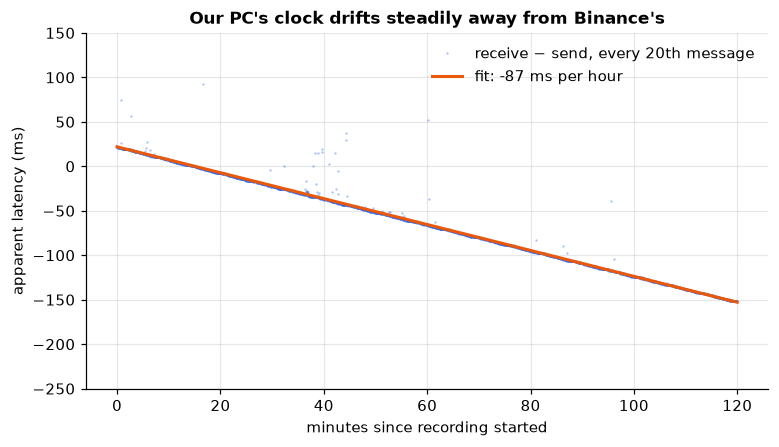

In [3]:
minutes = (ts - ts[0]).astype("int64") / 60_000
drift = ols(latency, minutes, names=["minutes"])
fig, ax = plt.subplots()
ax.plot(minutes[::20], latency[::20], ".", ms=1, color=BLUE, alpha=0.4, label="receive − send, every 20th message")
ax.plot(minutes, drift.beta[0] + drift.beta[1] * minutes, color=ORANGE, lw=2,
        label=f"fit: {drift.beta[1] * 60:+.0f} ms per hour")
ax.set(xlabel="minutes since recording started", ylabel="apparent latency (ms)", ylim=(-250, 150),
       title="Our PC's clock drifts steadily away from Binance's")
ax.legend()
save(fig, "10_clock_drift")
print(f"drift: {drift.beta[1] * 60:+.1f} ms per hour = {drift.beta[1] / 60_000 * 1e6:+.0f} parts per million")
print(f"apparent latency at the start: {drift.beta[0]:.0f} ms")

A straight line. The apparent latency falls by the same amount every minute, which is the signature of **clock
drift**: the PC's quartz oscillator runs slightly off, and Windows only re-syncs it with a time server
occasionally. Tens of parts per million is ordinary for consumer hardware, yet it's enough to swamp the real network
delay (a few tens of ms) within half an hour.

Lessons for any latency-sensitive work:
- **Know which clock each timestamp came from.** Here we use the exchange's matching-engine time (`T`) for all
  analysis, so our drifting clock doesn't matter.
- One-way latency can't be measured without synchronised clocks. HFT firms discipline theirs with GPS / PTP to
  within microseconds, and co-locate next to the matching engine so the true latency is microseconds too.

## The shape of the book

average size at best bid / ask: 6.70 / 8.99 BTC
average size at levels 2-20:    0.085 / 0.154 BTC per level
median price distance from level 1 to level 20: 2.6 USDT (26 ticks)


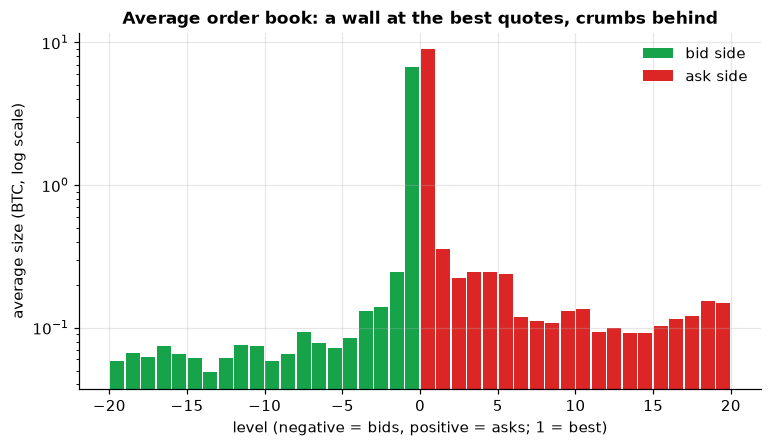

In [4]:
levels = np.arange(1, 21)
fig, ax = plt.subplots()
ax.bar(-levels + 0.5, depth["bid_qty"].mean(axis=0), width=0.9, color=GREEN, label="bid side")
ax.bar(levels - 0.5, depth["ask_qty"].mean(axis=0), width=0.9, color=RED, label="ask side")
ax.set(yscale="log", xlabel="level (negative = bids, positive = asks; 1 = best)", ylabel="average size (BTC, log scale)",
       title="Average order book: a wall at the best quotes, crumbs behind")
ax.legend()
save(fig, "10_book_shape")
gap_to_level20 = np.median(depth["ask_px"][:, 19] - depth["ask_px"][:, 0])
print(f"average size at best bid / ask: {depth['bid_qty'][:, 0].mean():.2f} / {depth['ask_qty'][:, 0].mean():.2f} BTC")
print(f"average size at levels 2-20:    {depth['bid_qty'][:, 1:].mean():.3f} / {depth['ask_qty'][:, 1:].mean():.3f} BTC per level")
print(f"median price distance from level 1 to level 20: {gap_to_level20:.1f} USDT ({gap_to_level20 / TICK:.0f} ticks)")

Almost all visible liquidity sits **at the best quote**. Levels 2–20 hold tiny amounts each, and the 20 levels
together span only a couple of USDT (about 0.003% of the price). This is the large-tick picture from chapter 1
taken to the extreme: makers crowd into the queue at the touch, because that's where fills happen. Anything behind
it is a small order (often someone's grid or a stale quote) that rarely trades before it's cancelled.

## Level-1 OFI: event-by-event vs 100 ms snapshots

We can compute level-1 OFI two ways: from **every** best-quote change (the `bookTicker` stream, like chapter 5),
or from the **100 ms snapshots**. Snapshots miss whatever happens and reverses within 100 ms.

In [5]:
lq_ts = to_ms(live_q.ts)
lq_mid = mid(live_q)
grid = time_grid(max(ts[0], lq_ts[0]), min(ts[-1], lq_ts[-1]), "1s")
dmid = np.diff(resample_last(lq_ts, lq_mid, grid))

e_events = ofi_events(live_q.bid, live_q.bid_qty, live_q.ask, live_q.ask_qty)
ofi_events_1s = sum_in_buckets(lq_ts, e_events, grid)

e_levels = ofi_events(depth["bid_px"], depth["bid_qty"], depth["ask_px"], depth["ask_qty"])   # (n, 20): one column per level
ofi_levels_1s = np.column_stack([sum_in_buckets(ts, e_levels[:, k], grid) for k in range(20)])

ok = ~np.isnan(dmid)
r_events = ols(dmid[ok], ofi_events_1s[ok])
r_snap = ols(dmid[ok], ofi_levels_1s[ok, 0])
print(f"R² of 1 s mid changes on level-1 OFI, every event:      {r_events.r2:.3f}")
print(f"R² of 1 s mid changes on level-1 OFI, 100 ms snapshots: {r_snap.r2:.3f}")

R² of 1 s mid changes on level-1 OFI, every event:      0.479
R² of 1 s mid changes on level-1 OFI, 100 ms snapshots: 0.338


Event-by-event OFI explains more than snapshot OFI. **Sampling resolution is information.** A lot happens at the
touch within 100 ms: queues get eaten and refilled, orders are posted and cancelled. This is one reason firms pay
for the fastest, most granular feeds.

## Does depth beyond level 1 help? (Honestly, out of sample)

Multi-level OFI (Xu, Gould & Howison 2018) puts the OFI at each of the top k levels into the regression as
separate variables. With 20 levels that's 20 coefficients, which is exactly the overfitting setting of chapter 9.
So fit on the first half of the recording and test on the second.

        in-sample R²  out-of-sample R²
levels                                
1              0.312             0.338
2              0.315             0.342
3              0.315             0.342
5              0.317             0.332
10             0.328             0.357
20             0.362             0.464


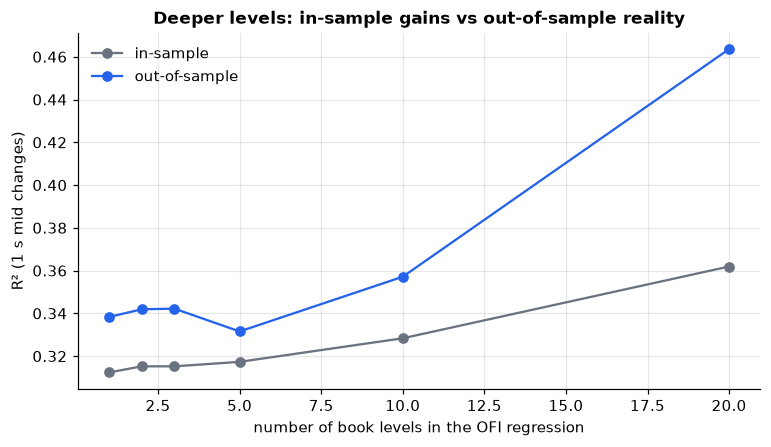

In [6]:
idx = np.flatnonzero(ok)
half = len(idx) // 2
tr, te = idx[:half], idx[half:]
rows = []
for k in [1, 2, 3, 5, 10, 20]:
    X = ofi_levels_1s[:, :k]
    r = ols(dmid[tr], X[tr])
    pred = r.beta[0] + X[te] @ r.beta[1:]
    r2_oos = 1 - np.sum((dmid[te] - pred) ** 2) / np.sum((dmid[te] - dmid[tr].mean()) ** 2)
    rows.append({"levels": k, "in-sample R²": r.r2, "out-of-sample R²": r2_oos})
table = pd.DataFrame(rows).set_index("levels")
print(table.round(3))

fig, ax = plt.subplots()
ax.plot(table.index, table["in-sample R²"], "o-", color=GREY, label="in-sample")
ax.plot(table.index, table["out-of-sample R²"], "o-", color=BLUE, label="out-of-sample")
ax.set(xlabel="number of book levels in the OFI regression", ylabel="R² (1 s mid changes)",
       title="Deeper levels: in-sample gains vs out-of-sample reality")
ax.legend()
save(fig, "10_multilevel_ofi")

Here deeper levels **do** carry information that survives out of sample: going from 1 to 20 levels lifts
out-of-sample R² from about 0.34 to about 0.46. Small orders sitting a few ticks behind the touch get added and
pulled as traders anticipate where the price is going, so their flow is informative even though their size is tiny.

Two honesty checks:
- Out-of-sample R² is *higher* than in-sample here. That doesn't mean the model got better on new data. The second
  hour was simply more predictable than the first, which says the relationship isn't perfectly stable over time
  (non-stationarity). With one recording, the exact numbers are fragile.
- In the first 20 minutes of this same recording, the deeper levels *didn't* help out of sample. Small samples
  give unstable answers. Two hours is enough to see the effect, but a careful study would use many days and report
  how often the improvement holds.

## The same market, 2½ years apart

Our historical day (Wednesday 27 March 2024) vs our recording. Caveat: one Saturday-evening recording against a
full weekday is a weak comparison, and a seasonality lesson in itself.

In [7]:
hist_q, hist_t = load_quotes(), aggregate_trades(load_trades())
def summary(q, trades_per_sec, label):
    st = spread_ticks(q, TICK)
    qts = to_ms(q.ts)
    dur = np.append(np.diff(qts).astype("int64"), 0).astype(float)
    secs = (qts[-1] - qts[0]).astype("int64") / 1000
    return {"": label,
            "mid price (USDT)": f"{mid(q).mean():,.0f}",
            "best-quote updates / s": f"{len(q) / secs:.0f}",
            "aggressive orders / s": f"{trades_per_sec:.1f}",
            "% of time spread = 1 tick": f"{(dur * (st == 1)).sum() / dur.sum():.1%}",
            "median size at best bid (BTC)": f"{q.bid_qty.median():.2f}"}
secs_live = (lq_ts[-1] - lq_ts[0]).astype("int64") / 1000
print(pd.DataFrame([
    summary(hist_q, len(hist_t) / 86400, "27 Mar 2024 (full day)"),
    summary(live_q, len(live_t) / secs_live, "our recording (2026)"),
]).set_index("").T.to_string())

                              27 Mar 2024 (full day) our recording (2026)
mid price (USDT)                              69,782               84,813
best-quote updates / s                           183                  109
aggressive orders / s                           16.8                  3.1
% of time spread = 1 tick                      98.7%               100.0%
median size at best bid (BTC)                   1.47                 5.64


Note: the live `aggTrade` stream merges fills of one taker order *at one price*, while our `aggregate_trades`
merges by millisecond and side. The two "orders per second" are close cousins, not identical definitions.

---
### Interview angle

<details><summary><b>"How would you measure your latency to an exchange?"</b></summary>

Compare exchange timestamps with your receive timestamps. That's only meaningful if clocks are synchronised
(NTP gives ~ms, PTP/GPS gives ~µs), and the negative "latencies" here show what happens when they aren't. Better:
measure round trips (send an order or ping, time the acknowledgement on your own clock) and halve it, with the
caveat that paths may be asymmetric.
</details>

<details><summary><b>"Would you use the full order book or just the top of book for a short-term model?"</b></summary>

Start with top of book. It carries most of the information for large-tick assets (chapter 6). Add depth only
if it improves *out-of-sample* performance, and expect that to depend on the asset. Also weigh the cost: full-depth
feeds are bigger, slower to process and more expensive.
</details>

### Try this yourself
1. Record a weekday US-open session (13:00–15:00 UTC): `scripts/record_binance.py --minutes 120`, then rerun this
   notebook. Delete `data/processed/live-*` first if you want a fresh start. Does deeper OFI help when the market is busy?
2. Record a less liquid contract (`--symbol dogeusdt`). Is its book shaped differently?
3. Compute the imbalance using the **sum of the top k levels** on each side. Does k > 1 predict the next mid move better than chapter 6's level-1 imbalance?